### import libraries

In [9]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt
from XLO_sim.XLO_sim import XLO_sim
from XLO_sim.Plot import XLO_plot
from XLO_sim import tools

import numpy.fft as fft

import scipy.constants as sp_const
au_in_eV = sp_const.value('atomic unit of energy') / sp_const.value('atomic unit of charge')

import multiprocessing as mp
import shutil

import pandas as pd

notebook_path = os.path.abspath("__file__")
notebook_directory = os.path.dirname(notebook_path)
base_directory = os.path.dirname(notebook_directory)

### Transmission

In [2]:
tpad = 1000
xpad = 64
ypad = 64

th_show = 2
w_show = 5

thx_show_min = -th_show
thx_show_max = th_show
thy_show_min = -th_show
thy_show_max = th_show
w_show_min = -w_show
w_show_max = w_show

### reading and plotting

In [3]:
figs_path = os.path.join(base_directory, 'figs')
if not os.path.exists(figs_path):
    os.makedirs(figs_path)

In [4]:
from collections import OrderedDict


def data_from_folder(folder_path):

    # print(os.listdir(folder_path))

    # Initialize the top-level dictionary to store accumulated arrays for each E_seed
    accumulated_arrays = {}

    for runs_Eseed_folder in os.listdir(folder_path):
        if not os.path.isdir(os.path.join(folder_path, runs_Eseed_folder)):
            continue  # Skip if it's not a directory
        # Specify the path to the folder containing the saved files
        runs_path = folder_path + '/' + runs_Eseed_folder

        # Find the YAML file in the folder
        yaml_file = None
        for file_name in os.listdir(runs_path):
            if file_name.endswith('.yaml'):
                yaml_file = os.path.join(runs_path, file_name)
                break

        if yaml_file is None:
            print(f"No YAML file found in {runs_path}")
            continue

        # Read the YAML file to get the E_seed value
        with open(yaml_file, 'r') as f:
            yaml_data = yaml.safe_load(f)
            E_seed_value = yaml_data['E_seed_uJ']
            
            # seed_FEL_bandwidth = yaml_data['seed_FEL_bandwidth']
            tgrid = yaml_data['tgrid']
            xgrid = yaml_data['xgrid']
            ygrid = yaml_data['ygrid']
            zgrid = yaml_data['zgrid']
            sigma1_Ka1_2p3 = yaml_data['sigma1_Ka1_2p3']
            sigma1_Ka1_other = yaml_data['sigma1_Ka1_other']
            seed_duration_FWHM_t = yaml_data['seed_duration_FWHM_t']
            
            aux_data = [tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t]

        # Initialize variables to store the accumulated arrays for the current E_seed
        if E_seed_value not in accumulated_arrays:
            accumulated_arrays[E_seed_value] = {}

        # Iterate over all files in the folder
        for file_name in os.listdir(runs_path):
            # Check if the file is a numpy savez_compressed file
            if file_name.endswith('.npz'):
                # Load the file
                file_path = os.path.join(runs_path, file_name)
                data = np.load(file_path)

                # Iterate over all arrays in the loaded file
                for array_name in data.files:
                    # Accumulate the arrays by averaging them
                    if array_name in accumulated_arrays[E_seed_value]:
                        accumulated_arrays[E_seed_value][array_name] += data[array_name]
                    else:
                        accumulated_arrays[E_seed_value][array_name] = data[array_name]

        # Divide each accumulated array by the number of files to get the average
        num_files = len([file_name for file_name in os.listdir(runs_path) if file_name.endswith('.npz')])
        # print(f'E_seed: {E_seed_value}, num_files: {num_files}')
        for array_name in accumulated_arrays[E_seed_value]:
            accumulated_arrays[E_seed_value][array_name] /= num_files

    # Sort the accumulated arrays by E_seed value
    sorted_accumulated_arrays = OrderedDict(sorted(accumulated_arrays.items(), key=lambda x: x[0], reverse=True))

    # Example of how to access the accumulated arrays for a specific E_seed
    # for E_seed_value, arrays in sorted_accumulated_arrays.items():
    #     print(f'E_seed: {E_seed_value}')
    #     for array_name, array_data in arrays.items():
    #         print(f'  Array name: {array_name}, shape: {array_data.shape}')
    
    return sorted_accumulated_arrays, aux_data, num_files

In [5]:
data_path = "../data/intensity_sweep_40_9_2"

In [6]:
Tshow_min = 0.15#0.4
Tshow_max = 0.5
w_show = 15
w_show_min = -w_show
w_show_max = w_show

sorted_accumulated_arrays, aux_data, num_files = data_from_folder(data_path)

tgrid, xgrid, ygrid, zgrid, sigma1_Ka1_2p3, sigma1_Ka1_other, seed_duration_FWHM_t = aux_data

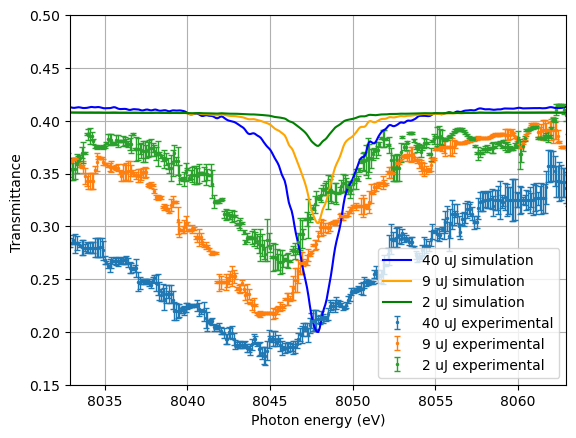

In [25]:
experimental_df = pd.read_csv("../data/transmittance_2_9_40uJ.csv")
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["40uJ_transmittance"], 
             experimental_df["40uJ_error"], label="40 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["9uJ_transmittance"], 
             experimental_df["9uJ_error"], label="9 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)
plt.errorbar(experimental_df["Photon_energy_eV"], experimental_df["2uJ_transmittance"], 
             experimental_df["2uJ_error"], label="2 uJ experimental", 
             fmt='.', capsize=2, ms=3, elinewidth=1)

E_seed_values = list(sorted_accumulated_arrays.keys())

colors = {
    40: "blue",
    9: "orange",
    2: "green"
}

hwKalpha1N = 8047.91

for E_seed_value, arrays in sorted_accumulated_arrays.items():
    womega_ar = arrays['womega_ar']
    I_int_thy_w_last = arrays['I_int_thy_w_last']
    I_int_thy_w_0 = arrays['I_int_thy_w_0']
    
    Tint_w = I_int_thy_w_last / I_int_thy_w_0

    energy_eV = hwKalpha1N + womega_ar
    
    plt.plot(energy_eV, Tint_w, color=colors[E_seed_value], label = str(E_seed_value) + ' uJ simulation')
    
plt.ylabel('Transmittance ')
plt.xlabel('Photon energy (eV)')
plt.ylim(Tshow_min, Tshow_max)
plt.xlim(hwKalpha1N - 15, hwKalpha1N + 15)
plt.legend()
plt.grid(True)
plt.savefig(figs_path + '/' + str_pars_calc + '.pdf')
plt.show()

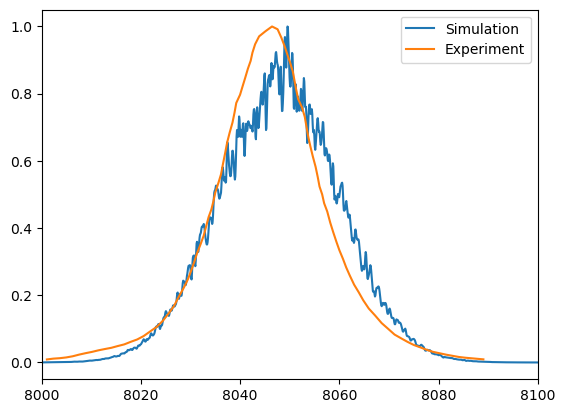

In [28]:
intensity_df = pd.read_csv("../data/intensity.csv")

I_int_thy_w_0 = sorted_accumulated_arrays[40]['I_int_thy_w_0']
plt.plot(energy_eV, I_int_thy_w_0/I_int_thy_w_0.min(), label="Simulation")
plt.plot(intensity_df["Photon_energy_eV"], intensity_df["Intensity"]/intensity_df["Intensity"].max(), label="Experiment")
plt.xlim(8000, 8100)
plt.legend()
plt.show()